<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/photon_wave_particle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

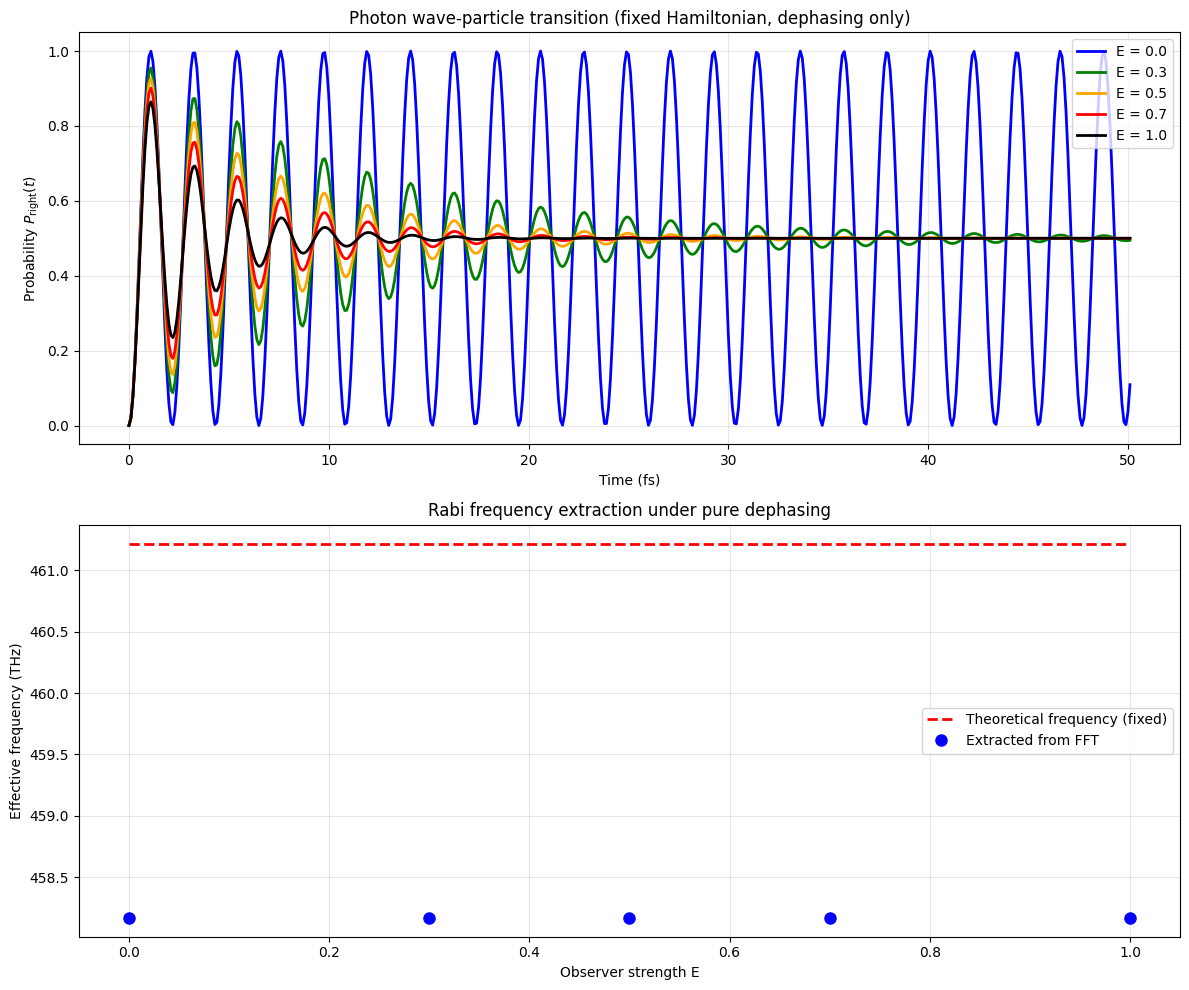


=== DTQEM v17.0 – Photon simulation results ===
Photon reference frequency ν₀ = 461.219 THz
E_ext | P(t_final) | Extracted ν (THz) | Theory ν (THz)
------------------------------------------------------------
  0.0 |     0.1090 |         458.167 |       461.219
  0.3 |     0.4946 |         458.167 |       461.219
  0.5 |     0.4997 |         458.167 |       461.219
  0.7 |     0.5000 |         458.167 |       461.219
  1.0 |     0.5000 |         458.167 |       461.219


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.fft import fft, fftfreq

# ============================================================
# 1. ثوابت الفوتون (ضوء أحمر, 650 nm)
# ============================================================
hbar = 1.0545718e-34          # J·s
lambda_nm = 650
c = 299792458
omega0 = 2 * np.pi * c / (lambda_nm * 1e-9)   # rad/s
nu0 = omega0 / (2 * np.pi)                    # Hz

# معامل التبديد الأساسي
gamma0 = 0.1 * omega0          # 1/s

# زمن المحاكاة
t_max = 50e-15                 # 50 fs
dt = 0.1e-15                   # 0.1 fs
t_arr = np.arange(0, t_max+dt, dt)
steps = len(t_arr)

# مصفوفات باولي
sx = np.array([[0,1],[1,0]], dtype=complex)
sz = np.array([[1,0],[0,-1]], dtype=complex)
I = np.eye(2, dtype=complex)

# ============================================================
# 2. بناء الليوفيليان (باستخدام H.conj().T للتوافق مع DTQEM)
# ============================================================
def build_liouvillian(H, L_list):
    Lv = -1j/hbar * (np.kron(H, I) - np.kron(I, H.conj().T))
    for Lk in L_list:
        Lk_dag = Lk.conj().T
        Lv += np.kron(Lk, Lk.conj())
        Lk_dag_Lk = Lk_dag @ Lk
        Lv += -0.5 * (np.kron(Lk_dag_Lk, I) + np.kron(I, Lk_dag_Lk.T))
    return Lv

# ============================================================
# 3. المحاكاة (الهاميلتوني ثابت، التبديد فقط يعتمد على E)
# ============================================================
def run_photon_simulation(E_ext):
    H = (hbar * omega0 / 2.0) * sx          # ثابت، لا يعتمد على E
    L_ops = []
    if E_ext > 0:
        L_ops.append(np.sqrt(gamma0 * E_ext) * sz)

    L = build_liouvillian(H, L_ops)
    prop = expm(L * dt)

    rho = np.array([[1,0],[0,0]], dtype=complex)   # |0⟩ (wave-like state)
    P = np.zeros(steps)

    for i in range(steps):
        if i > 0:
            rho_vec = prop @ rho.flatten('C')
            rho = rho_vec.reshape(2,2)
            rho = 0.5 * (rho + rho.conj().T)        # enforce Hermiticity
        P[i] = rho[1,1].real
    return P

# ============================================================
# 4. استخراج التردد المهيمن عبر FFT
# ============================================================
def extract_dominant_frequency(P, t_arr):
    N = len(P)
    T = t_arr[1] - t_arr[0]
    yf = fft(P - np.mean(P))
    xf = fftfreq(N, T)[:N//2]
    power = np.abs(yf[:N//2])**2
    peak_idx = np.argmax(power[1:]) + 1
    return xf[peak_idx]

# ============================================================
# 5. تشغيل المحاكاة وعرض النتائج
# ============================================================
E_vals = [0.0, 0.3, 0.5, 0.7, 1.0]
colors = ['blue', 'green', 'orange', 'red', 'black']

plt.figure(figsize=(12,10))

# اللوحة 1: السلوك الزمني
plt.subplot(2,1,1)
for E, col in zip(E_vals, colors):
    P = run_photon_simulation(E)
    plt.plot(t_arr*1e15, P, color=col, lw=2, label=f'E = {E}')
plt.xlabel('Time (fs)')
plt.ylabel('Probability $P_{\\mathrm{right}}(t)$')
plt.title('Photon wave‑particle transition (fixed Hamiltonian, dephasing only)')
plt.legend()
plt.grid(alpha=0.3)

# اللوحة 2: التردد المستخرج
plt.subplot(2,1,2)
freq_th = nu0 * np.ones_like(E_vals)   # النظرية: تردد ثابت (لا تغيير في الطاقة)
freq_ext = []
for E in E_vals:
    P = run_photon_simulation(E)
    f_ext = extract_dominant_frequency(P, t_arr)
    freq_ext.append(f_ext)

plt.plot(E_vals, freq_th/1e12, 'r--', lw=2, label='Theoretical frequency (fixed)')
plt.plot(E_vals, np.array(freq_ext)/1e12, 'bo', markersize=8, label='Extracted from FFT')
plt.xlabel('Observer strength E')
plt.ylabel('Effective frequency (THz)')
plt.title('Rabi frequency extraction under pure dephasing')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# طباعة الجدول
print("\n=== DTQEM v17.0 – Photon simulation results ===")
print(f"Photon reference frequency ν₀ = {nu0/1e12:.3f} THz")
print("E_ext | P(t_final) | Extracted ν (THz) | Theory ν (THz)")
print("-" * 60)
for E in E_vals:
    P = run_photon_simulation(E)
    f_ext = extract_dominant_frequency(P, t_arr) / 1e12
    print(f"{E:5.1f} | {P[-1]:10.4f} | {f_ext:15.3f} | {nu0/1e12:13.3f}")